#KMEANS SEM PCA

In [ ]:
import joblib
from sklearn.cluster import KMeans
import urllib.request

# URL do modelo
model_url = 'https://github.com/celeron550/Dataset-Alunos-ECT/raw/refs/heads/main/modelos/kmeans.joblib'
# Nome do arquivo local temporário
local_filename = 'kmeans.joblib'

# Baixa o arquivo do modelo
urllib.request.urlretrieve(model_url, local_filename)

# Carrega o modelo do arquivo local
kmeans = joblib.load(local_filename)

print(f"Modelo KMeans carregado com sucesso de {local_filename}")

Modelo KMeans carregado com sucesso de kmeans.joblib


Valores dos Centróides (Perfil Médio de cada Cluster):


,s1_ECT2101_nota,s1_ECT2101_status,s1_ECT2102_nota,s1_ECT2102_status,s1_ECT2103_nota,s1_ECT2103_status,s1_ECT2104_nota,s1_ECT2104_status,s1_ECT2105_nota,s1_ECT2105_status,...,s1_ECT2401_status,s1_ECT2402_nota,s1_ECT2402_status,s1_ECT2403_nota,s1_ECT2403_status,s1_faltas_no_periodo,s1_media_periodo,s1_reprovacoes_no_periodo,s1_total_faltas_acumulado,s1_total_reprovacoes_acumulado
Cluster 0,0.216285,0.130522,0.140663,0.038153,0.111888,0.052209,0.307530,0.214859,0.634292,0.911647,...,0.500000,5.204170e-18,0.500000,5.529431e-18,5.637851e-18,0.107970,0.359695,0.0,0.107970,0.0
Cluster 1,0.096462,0.131731,0.047635,0.087500,0.026827,0.081731,0.076077,0.095192,0.210145,0.291346,...,0.496154,4.774536e-03,0.500962,1.923077e-03,1.923077e-03,0.184958,0.121195,0.0,0.184958,0.0
Cluster 2,0.578723,0.796537,0.496234,0.625541,0.465043,0.619048,0.608247,0.898268,0.692464,0.958874,...,0.500000,4.987330e-18,0.500000,5.421011e-18,5.529431e-18,0.060931,0.616201,0.0,0.060931,0.0


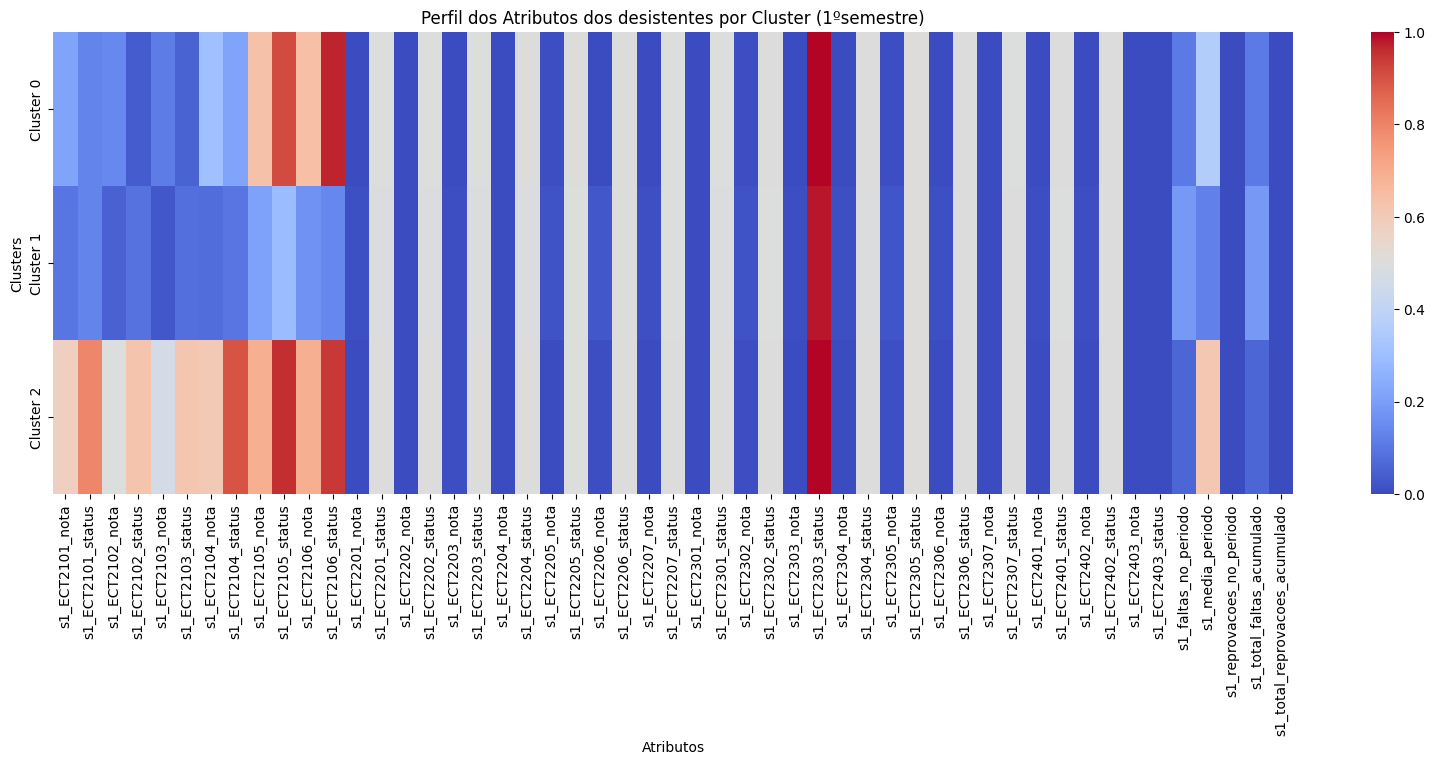

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obtendo os centros dos clusters
centroids = kmeans.cluster_centers_

# Nomes das colunas (atributos)
feature_names = ['s1_ECT2101_nota', 's1_ECT2101_status', 's1_ECT2102_nota',
       's1_ECT2102_status', 's1_ECT2103_nota', 's1_ECT2103_status',
       's1_ECT2104_nota', 's1_ECT2104_status', 's1_ECT2105_nota',
       's1_ECT2105_status', 's1_ECT2106_nota', 's1_ECT2106_status',
       's1_ECT2201_nota', 's1_ECT2201_status', 's1_ECT2202_nota',
       's1_ECT2202_status', 's1_ECT2203_nota', 's1_ECT2203_status',
       's1_ECT2204_nota', 's1_ECT2204_status', 's1_ECT2205_nota',
       's1_ECT2205_status', 's1_ECT2206_nota', 's1_ECT2206_status',
       's1_ECT2207_nota', 's1_ECT2207_status', 's1_ECT2301_nota',
       's1_ECT2301_status', 's1_ECT2302_nota', 's1_ECT2302_status',
       's1_ECT2303_nota', 's1_ECT2303_status', 's1_ECT2304_nota',
       's1_ECT2304_status', 's1_ECT2305_nota', 's1_ECT2305_status',
       's1_ECT2306_nota', 's1_ECT2306_status', 's1_ECT2307_nota',
       's1_ECT2307_status', 's1_ECT2401_nota', 's1_ECT2401_status',
       's1_ECT2402_nota', 's1_ECT2402_status', 's1_ECT2403_nota',
       's1_ECT2403_status', 's1_faltas_no_periodo', 's1_media_periodo',
       's1_reprovacoes_no_periodo', 's1_total_faltas_acumulado',
       's1_total_reprovacoes_acumulado']

# Criando o DataFrame corretamente:
# rows (index) = Clusters, columns = Atributos
df_centroids = pd.DataFrame(centroids, columns=feature_names, index=[f'Cluster {i}' for i in range(len(centroids))])

print("Valores dos Centróides (Perfil Médio de cada Cluster):")
display(df_centroids)

# Visualização via Heatmap
plt.figure(figsize=(20, 6))
sns.heatmap(df_centroids, annot=False, cmap='coolwarm')
plt.title('Perfil dos Atributos dos desistentes por Cluster (1ºsemestre)')
plt.xlabel('Atributos')
plt.ylabel('Clusters')
plt.show()

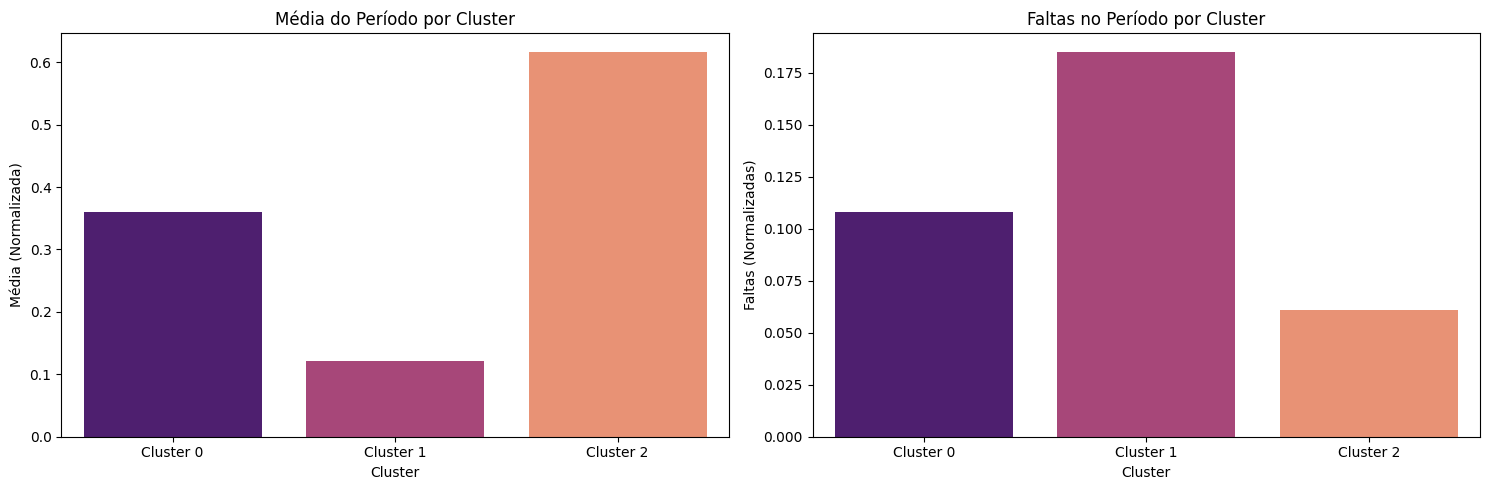

Resumo dos indicadores de risco:


,s1_faltas_no_periodo,s1_media_periodo,s1_total_faltas_acumulado
Cluster 0,0.107970,0.359695,0.107970
Cluster 1,0.184958,0.121195,0.184958
Cluster 2,0.060931,0.616201,0.060931


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionando indicadores chave para análise de evasão
indicadores_evasao = ['s1_faltas_no_periodo', 's1_media_periodo', 's1_total_faltas_acumulado']
df_evasao = df_centroids[indicadores_evasao]

# Plotando comparação direta
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=df_evasao.index, y='s1_media_periodo', data=df_evasao, ax=axes[0], palette='magma', hue=df_evasao.index, legend=False)
axes[0].set_title('Média do Período por Cluster')
axes[0].set_ylabel('Média (Normalizada)')
axes[0].set_xlabel('Cluster')

sns.barplot(x=df_evasao.index, y='s1_faltas_no_periodo', data=df_evasao, ax=axes[1], palette='magma', hue=df_evasao.index, legend=False)
axes[1].set_title('Faltas no Período por Cluster')
axes[1].set_ylabel('Faltas (Normalizadas)')
axes[1].set_xlabel('Cluster')

plt.tight_layout()
plt.show()

print("Resumo dos indicadores de risco:")
display(df_evasao)